In [1]:
import pandas as pd
import numpy as np
import os
import sys

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df

,filename,xmin,ymin,xmax,ymax,class
0,0003110600042104_20230711_FL01_esic_esic/00031...,897,115,995,260,Ablagerung
1,0003110600042104_20230711_FL01_esic_esic/00031...,871,0,1029,1633,Riss
2,0003110600042104_20230711_FL01_esic_esic/00031...,897,931,995,1076,Ablagerung
3,0003110600042104_20230711_FL01_esic_esic/00031...,871,0,1029,1633,Riss
4,0003110600042104_20230711_FL01_esic_esic/00031...,897,114,995,259,Ablagerung
...,...,...,...,...,...,...
218019,9004250290042501_20230912_FL01_esic_esic/90042...,11,1270,262,1633,nicht lernen
218020,9004250290042501_20230912_FL01_esic_esic/90042...,11,0,262,562,nicht lernen
218021,9004250290042501_20230912_FL01_esic_esic/90042...,754,0,886,1633,nicht lernen
218022,9004250290042501_20230912_FL01_esic_esic/90042...,11,453,262,1378,nicht lernen


## Columns

In [4]:
# Count of unique filenames
unique_filenames = df['filename'].nunique()

# Percentage of unique filenames
unique_filenames_percentage = (unique_filenames / len(df)) * 100

# Count of unique labels
unique_labels = df['class'].nunique()

print(f"Unique filenames: {unique_filenames}")
print(f"Unique filenames percentage: {unique_filenames_percentage:.2f}%")
print(f"Unique labels: {unique_labels}")

# Total count of filenames per label
filenames_per_label = df['class'].value_counts()
print(f"Total filenames per label:\n{filenames_per_label}")

# Percentage of filenames per label
filenames_per_label_percentage = (filenames_per_label / len(df)) * 100
print(f"Percentage of filenames per label:\n{filenames_per_label_percentage}")

# combine last 2 values into one table
# Count of unique filenames per label
filenames_per_label_unique = df.groupby('class')['filename'].nunique()
print(f"Unique filenames per label:\n{filenames_per_label_unique}")

# Percentage of unique filenames per label
# Count of unique filenames per label
# Count of unique filenames per label
filenames_per_label_percentage_unique = (filenames_per_label_unique / df['filename'].nunique()) * 100
print(f"Percentage of unique filenames per label:\n{filenames_per_label_percentage_unique}")

# Create new dataframe with the above values
df_summary = pd.DataFrame({
    'Total Filenames': filenames_per_label,
    'Percentage of Filenames': filenames_per_label_percentage,
    'Unique Filenames': filenames_per_label_unique,
    'Percentage of Unique Filenames': filenames_per_label_percentage_unique
})

Unique filenames: 91599
Unique filenames percentage: 42.01%
Unique labels: 11
Total filenames per label:
class
Ablagerung        53108
Materialabtrag    43783
Lageabweichung    36235
Riss              19647
Muffenschaden     16800
Anschluss         15397
Wurzel            13830
nicht lernen      10620
Hindernis          6377
Bruch              1131
Deformation        1096
Name: count, dtype: int64
Percentage of filenames per label:
class
Ablagerung        24.358786
Materialabtrag    20.081734
Lageabweichung    16.619730
Riss               9.011393
Muffenschaden      7.705574
Anschluss          7.062067
Wurzel             6.343338
nicht lernen       4.871023
Hindernis          2.924907
Bruch              0.518750
Deformation        0.502697
Name: count, dtype: float64
Unique filenames per label:
class
Ablagerung        28115
Anschluss         12129
Bruch               852
Deformation         951
Hindernis          4617
Lageabweichung    26532
Materialabtrag    24273
Muffenschaden     14

In [6]:
df_summary = df_summary.reset_index()
df_summary.columns = ['Class', 'Total Filenames', 'Percentage of Filenames', 'Unique Filenames', 'Percentage of Unique Filenames']
df_summary = df_summary.set_index('Class')
df_summary = df_summary.sort_values(by='Total Filenames', ascending=False)
df_summary.to_csv('summary.csv')
df_summary

,Total Filenames,Percentage of Filenames,Unique Filenames,Percentage of Unique Filenames
Class,,,,
Ablagerung,53108,24.358786,28115,30.693567
Materialabtrag,43783,20.081734,24273,26.499198
Lageabweichung,36235,16.619730,26532,28.965382
Riss,19647,9.011393,11499,12.553630
Muffenschaden,16800,7.705574,14559,15.894278
Anschluss,15397,7.062067,12129,13.241411
Wurzel,13830,6.343338,9682,10.569984
nicht lernen,10620,4.871023,8469,9.245734
Hindernis,6377,2.924907,4617,5.040448


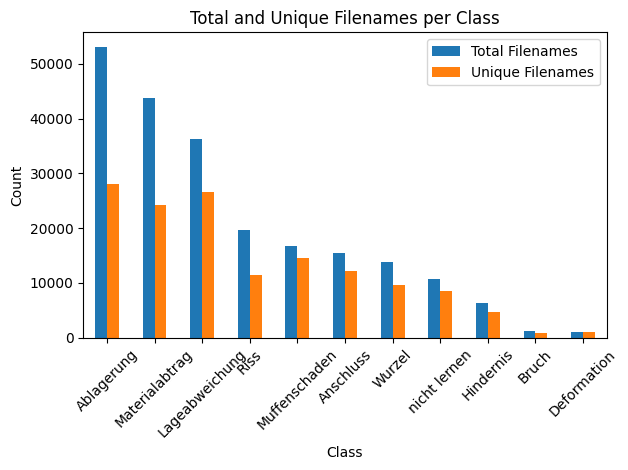

In [7]:
# Plot the data
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

fig, ax = plt.subplots()
df_summary[['Total Filenames', 'Unique Filenames']].plot(kind='bar', ax=ax)
ax.set_title('Total and Unique Filenames per Class')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(df_summary.index, rotation=45)
ax.legend(['Total Filenames', 'Unique Filenames'])
plt.tight_layout()
plt.savefig('summary.png')
plt.show()

Total images: 91599
Images with overlapping bboxes: 55150 (60.2%)
Average bboxes per image: 2.38
Median bboxes per image: 2


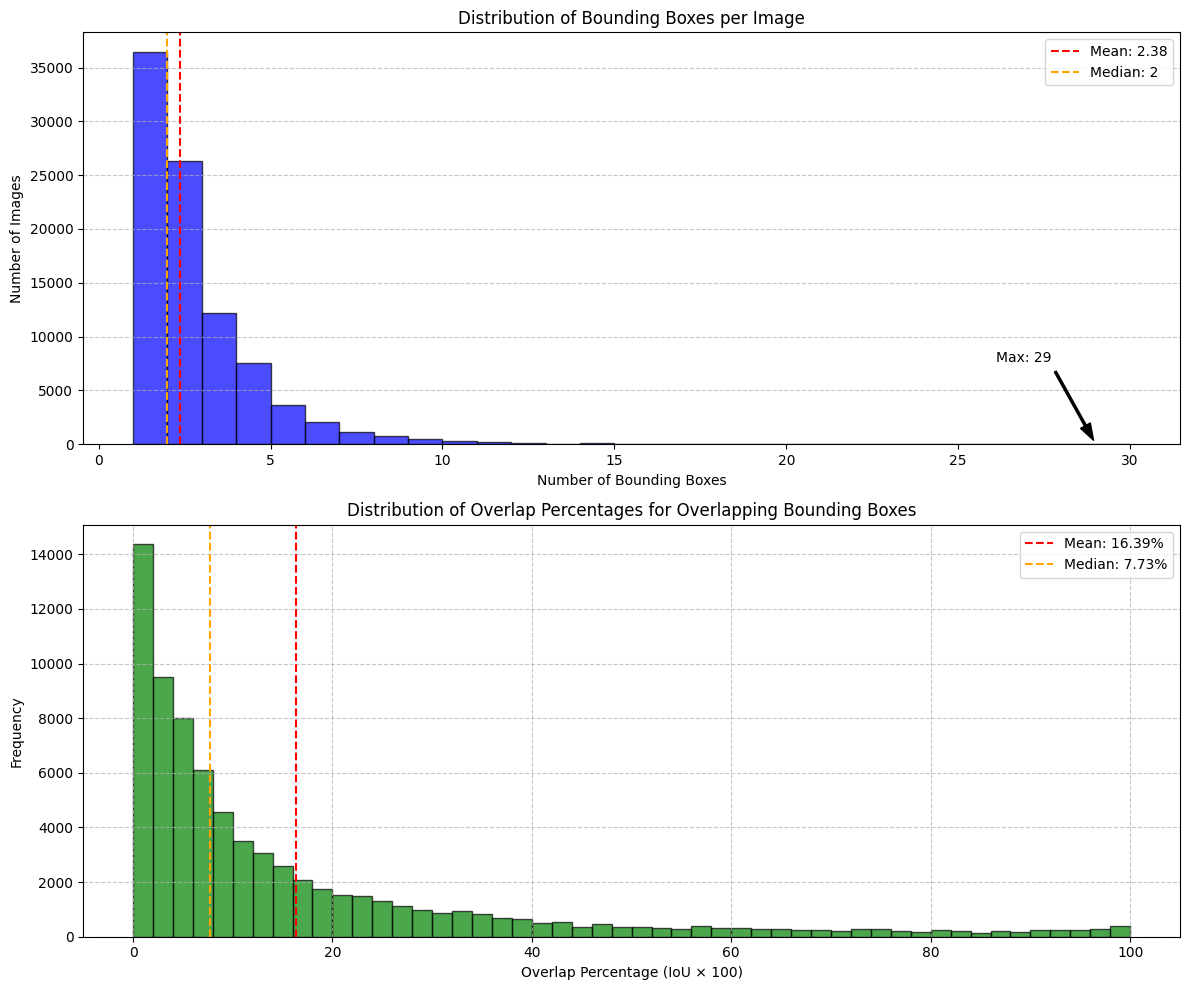

Total images analyzed: 91599
Images with overlapping bboxes: 55150 (60.2%)
Average bboxes per image: 2.38
Median bboxes per image: 2
Maximum bboxes in a single image: 29
Average overlap percentage (IoU): 16.39%
Median overlap percentage (IoU): 7.73%


<Figure size 640x480 with 0 Axes>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Function to calculate IoU (Intersection over Union)
def calculate_iou(box1, box2):
    # Extract coordinates
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # Calculate area of intersection
    x_left = max(x1_min, x2_min)
    y_top = max(y1_min, y2_min)
    x_right = min(x1_max, x2_max)
    y_bottom = min(y1_max, y2_max)
    
    # Check if there is an overlap
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    
    # Calculate area of both boxes
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    
    # Calculate IoU
    iou = intersection_area / float(box1_area + box2_area - intersection_area)
    return iou

# Calculate bboxes per image and overlapping bboxes
bbox_counts_per_image = {}
overlaps_per_image = {}
overlap_percentages = []

# Group by filename
for filename, group in df.groupby('filename'):
    # Get all bboxes in this image
    bboxes = group[['xmin', 'ymin', 'xmax', 'ymax']].values
    num_bboxes = len(bboxes)
    bbox_counts_per_image[filename] = num_bboxes
    
    # Count overlapping pairs
    overlap_count = 0
    total_pairs = 0
    
    # Calculate overlaps
    for i in range(len(bboxes)):
        for j in range(i+1, len(bboxes)):
            total_pairs += 1
            iou = calculate_iou(bboxes[i], bboxes[j])
            if iou > 0:  # Boxes overlap
                overlap_count += 1
                overlap_percentages.append(iou * 100)  # Store as percentage
    
    # Store the count of overlapping pairs for this image
    if total_pairs > 0:
        overlaps_per_image[filename] = (overlap_count, overlap_count / total_pairs * 100)

# Extract counts for histograms
bbox_counts = list(bbox_counts_per_image.values())

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Histogram of number of bboxes per image
max_bins = min(50, max(bbox_counts))
ax1.hist(bbox_counts, bins=range(1, max_bins + 2), color='blue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Number of Bounding Boxes')
ax1.set_ylabel('Number of Images')
ax1.set_title('Distribution of Bounding Boxes per Image')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add statistics to the first plot
avg_bboxes = np.mean(bbox_counts)
median_bboxes = np.median(bbox_counts)
max_bboxes = max(bbox_counts)
ax1.axvline(avg_bboxes, color='red', linestyle='--', label=f'Mean: {avg_bboxes:.2f}')
ax1.axvline(median_bboxes, color='orange', linestyle='--', label=f'Median: {median_bboxes:.0f}')
ax1.legend()

# Add text annotation for maximum
ax1.annotate(f'Max: {max_bboxes}', 
             xy=(max_bboxes, 0), 
             xytext=(max_bboxes - max_bins/10, ax1.get_ylim()[1]/5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10)

# Plot 2: Histogram of overlap percentages (only if there are overlaps)
if overlap_percentages:
    ax2.hist(overlap_percentages, bins=50, color='green', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Overlap Percentage (IoU × 100)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Overlap Percentages for Overlapping Bounding Boxes')
    ax2.grid(linestyle='--', alpha=0.7)

    # Add statistics to the second plot
    avg_overlap = np.mean(overlap_percentages)
    median_overlap = np.median(overlap_percentages)
    ax2.axvline(avg_overlap, color='red', linestyle='--', label=f'Mean: {avg_overlap:.2f}%')
    ax2.axvline(median_overlap, color='orange', linestyle='--', label=f'Median: {median_overlap:.2f}%')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'No overlapping bounding boxes found', 
             horizontalalignment='center', verticalalignment='center',
             transform=ax2.transAxes, fontsize=14)

# Overall statistics
total_images = len(bbox_counts_per_image)
images_with_overlaps = len(overlaps_per_image)
percent_images_with_overlaps = images_with_overlaps / total_images * 100 if total_images > 0 else 0

# Add text box with statistics
stats_text = (
    f"Total images: {total_images}\n"
    f"Images with overlapping bboxes: {images_with_overlaps} ({percent_images_with_overlaps:.1f}%)\n"
    f"Average bboxes per image: {avg_bboxes:.2f}\n"
    f"Median bboxes per image: {median_bboxes:.0f}"
)

print(stats_text)


# Save the figure
fig.tight_layout()
# Show the plots
plt.show()
# Save the figure
plt.savefig('bbox_analysis.png', dpi=600)


# Print some statistics
print(f"Total images analyzed: {total_images}")
print(f"Images with overlapping bboxes: {images_with_overlaps} ({percent_images_with_overlaps:.1f}%)")
print(f"Average bboxes per image: {avg_bboxes:.2f}")
print(f"Median bboxes per image: {median_bboxes:.0f}")
print(f"Maximum bboxes in a single image: {max_bboxes}")
if overlap_percentages:
    print(f"Average overlap percentage (IoU): {avg_overlap:.2f}%")
    print(f"Median overlap percentage (IoU): {median_overlap:.2f}%")
else:
    print("No overlapping bounding boxes found.")

# Aditya, please include the text just above this line in the presentation too. Thank you

In [8]:
# 0505653305056519_20230919_FL01_esic_esic/0505653305056519_20230919_FL01_esic_esic_x000000_y0816_w1633_h1633.png